In [19]:
import os
import numpy as np
import matplotlib.pyplot as plt
import sys         
import xarray as xr
import NooneCurves as NC 
import pandas as pd
import seaborn as sns

In [20]:
# Some initial values for testing
del0 = -400.    # Try -360 ....
delp = -30. 
eta  = 0.995
hsrc = 0.80 
nn   = 1000     # It needs to be this large to get precision in the searches
pcld = 85000.
ps = 1000.e2                    # approximate surface pressure
q0   = 0.9 
qmin = 11.
tsrc = 300. 

In [21]:
inst = 'TES'
band = 'S'
ON1 = 290
CE1 = 111
ON2 = 'a'
CE2 = 'b'

#sat_ds = xr.open_dataset('/Users/ellendyer/Documents/GitHub/Isotopes_F4R/data/all_tes_cb.nc')
#sat_ds = xr.open_dataset('/Users/ellendyer/Documents/GitHub/Isotopes_F4R/data/tropess_airs_s_cb.nc')
#sat_ds = sat_ds.rename({'time':'timedatum'})
sat_ds = xr.open_dataset('/Users/ellendyer/Documents/GitHub/Isotopes_F4R/data/tes_s_cb_007.nc')

#sat_ds = sat_ds.where((sat_ds['pressure']>550)&(sat_ds['pressure']<825),drop=True)
sat_ds = sat_ds.where(sat_ds['pressure']>825)
print(sat_ds.timedatum)

sat_ds = sat_ds.sel(timedatum=slice('2004-01-01','2014-12-31'))

<xarray.DataArray 'timedatum' (timedatum: 1651)> Size: 13kB
array(['2004-09-20T12:39:17.893447000', '2004-09-20T12:40:39.789869000',
       '2004-10-10T12:15:50.572497000', ..., '2015-12-22T12:47:20.724305000',
       '2015-12-22T12:47:42.570784000', '2015-12-22T12:48:05.069437000'],
      shape=(1651,), dtype='datetime64[ns]')
Coordinates:
  * timedatum  (timedatum) datetime64[ns] 13kB 2004-09-20T12:39:17.893447 ......


In [22]:
ON = ON1
CE = CE1
pppon = ON-(20*3)
ppon = ON-(20*2)
pon = ON-20
on = ON
ons = ON+20
onss = ON+(20*2)
pcesson = CE-(20*2)
cesson = CE-20
cess = CE
cesss = CE+20
print(pppon)


230


In [23]:
#S1 onset

mam_seas = {}
mam_seas['60-40 days pre-onset'] = sat_ds.where((sat_ds['timedatum.dayofyear']>pppon)&(sat_ds['timedatum.dayofyear']<pppon+20),drop=True)
mam_seas['40-20 days pre-onset'] = sat_ds.where((sat_ds['timedatum.dayofyear']>ppon)&(sat_ds['timedatum.dayofyear']<ppon+20),drop=True)
mam_seas['20 days to onset'] = sat_ds.where((sat_ds['timedatum.dayofyear']>pon)&(sat_ds['timedatum.dayofyear']<pon+20),drop=True)
mam_seas['onset to 20 days'] = sat_ds.where((sat_ds['timedatum.dayofyear']>on)&(sat_ds['timedatum.dayofyear']<on+20),drop=True)
mam_seas['20-40 days post-onset'] = sat_ds.where((sat_ds['timedatum.dayofyear']>ons)&(sat_ds['timedatum.dayofyear']<ons+20),drop=True)
mam_seas['40-60 days post-onset'] = sat_ds.where((sat_ds['timedatum.dayofyear']>onss)&(sat_ds['timedatum.dayofyear']<onss+20),drop=True)

mam_seas['40-20 days pre-cessation'] = sat_ds.where((sat_ds['timedatum.dayofyear']>pcesson)&(sat_ds['timedatum.dayofyear']<pcesson+20),drop=True)
mam_seas['20 days to cessation'] = sat_ds.where((sat_ds['timedatum.dayofyear']>cesson)&(sat_ds['timedatum.dayofyear']<cesson+20),drop=True)
mam_seas['cessation to post-20 days'] = sat_ds.where((sat_ds['timedatum.dayofyear']>cess)&(sat_ds['timedatum.dayofyear']<cess+20),drop=True)
mam_seas['post 20 days - post 40 days'] = sat_ds.where((sat_ds['timedatum.dayofyear']>cesss)&(sat_ds['timedatum.dayofyear']<cesss+20),drop=True)


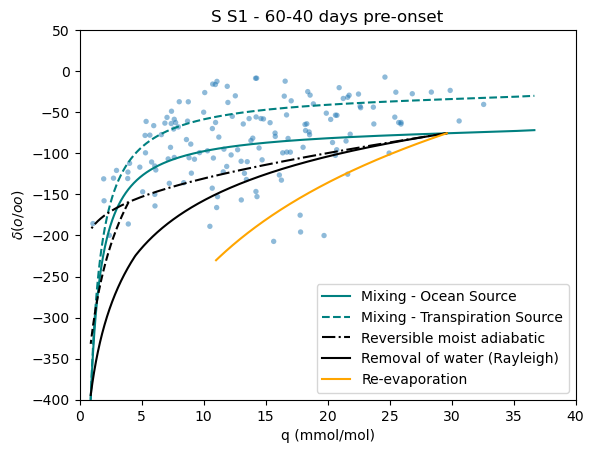

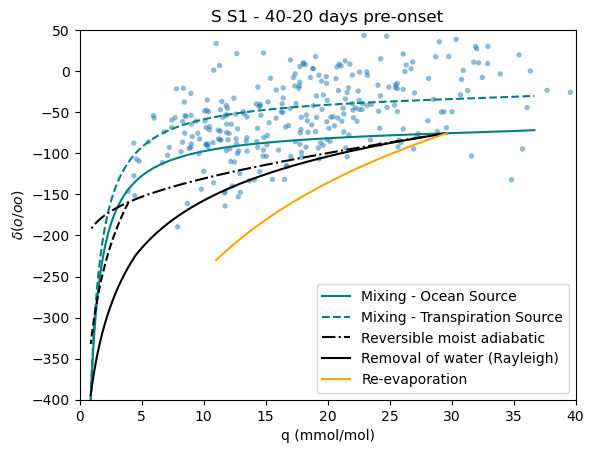

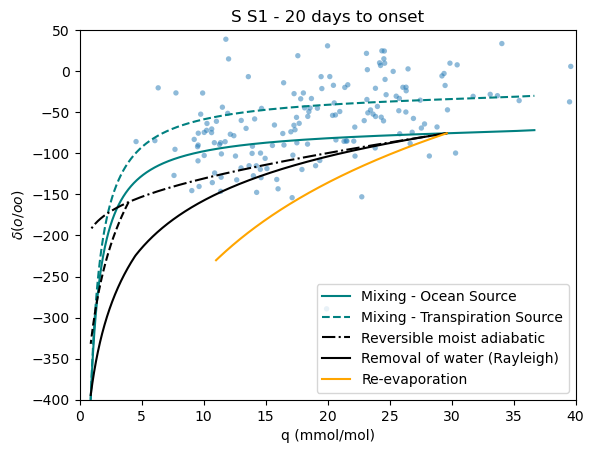

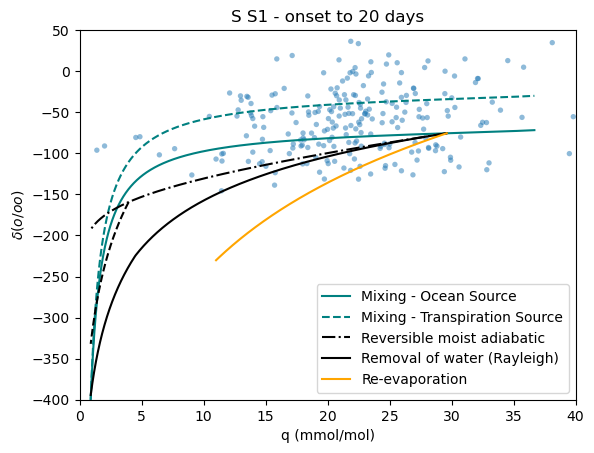

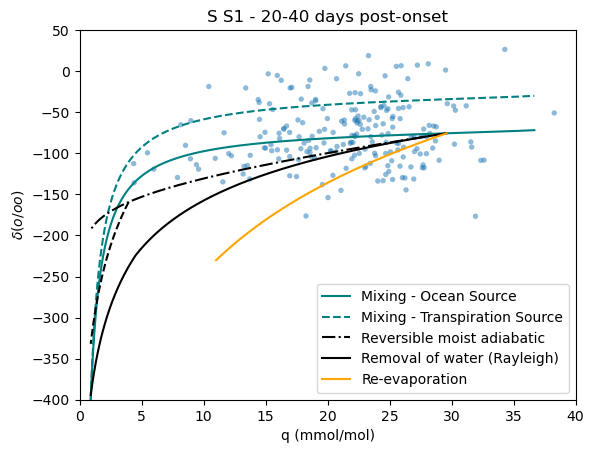

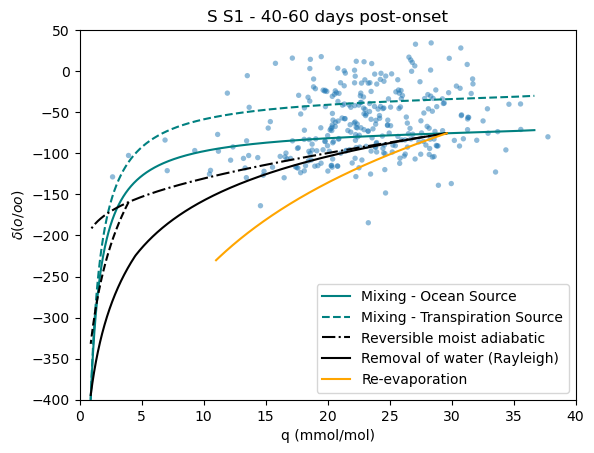

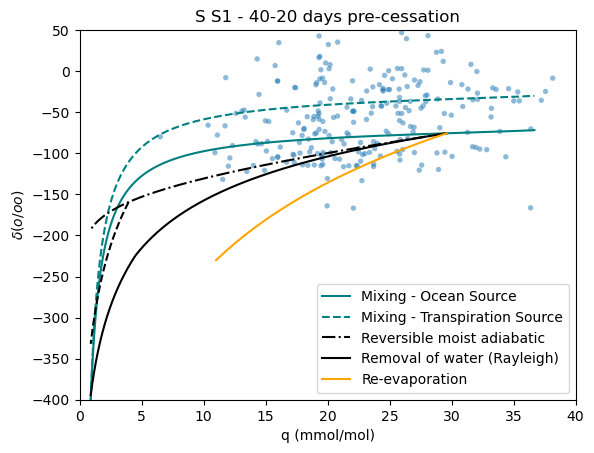

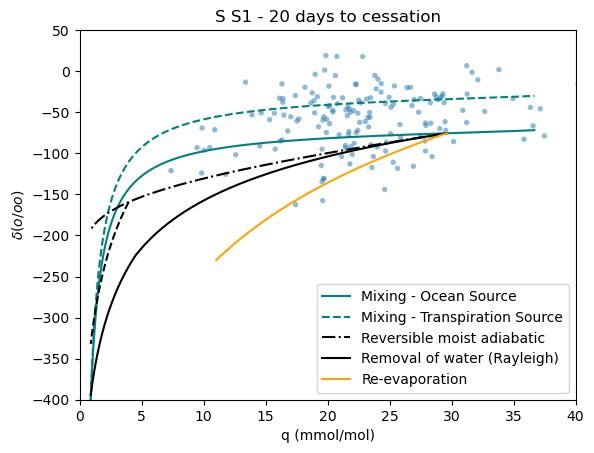

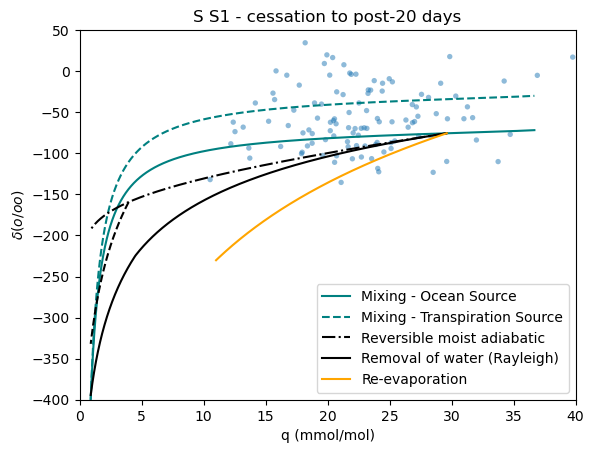

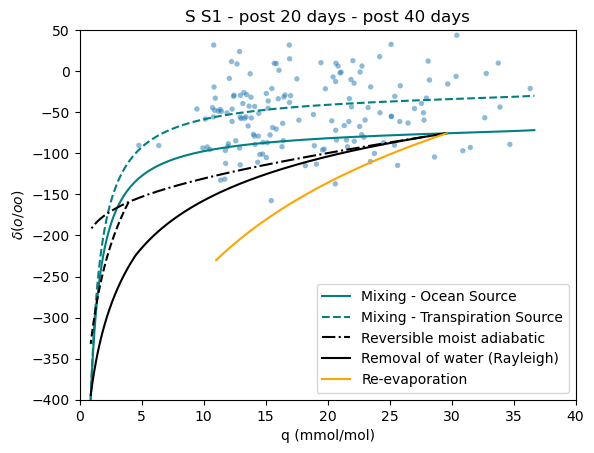

In [24]:
for s in mam_seas:
    
    deltaD = mam_seas[s]['deltaD']
    qh2o = 1000.*mam_seas[s]['H2O']
    
    
    plt.xlim(0,40)
    plt.ylim(-400,50)
    plt.scatter(qh2o,deltaD,s=15,alpha=0.5,edgecolors='none')

    NC.noone_curves(tsrc,q0,del0)    # Run and produce plot
    
    plt.legend(loc='best')
    plt.title(band+' S1 - '+s)
    plt.savefig('/Users/ellendyer/Documents/GitHub/Isotopes_F4R/plots/'+inst+'_noone_curves_'+band+'_S1_'+s+'.png')

    plt.show()
    plt.clf()
    plt.close()

Axes(0.125,0.11;0.775x0.77)


TypeError: Axes.scatter() got multiple values for argument 'ax'

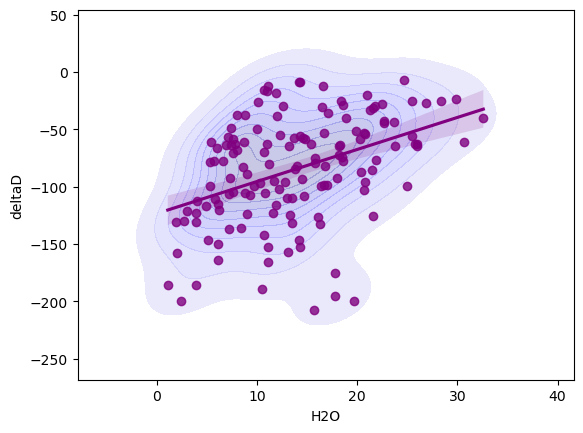

In [57]:
for s in mam_seas:
    
    df = mam_seas[s].to_dataframe()
    df['H2O'] = df['H2O']*1000.
    
    ax = sns.kdeplot(data=df, x="H2O", y="deltaD", fill=True,
                alpha=0.3,color='blue')
                #levels=7, thresh=.2)
    #g.plot_marginals(sns.boxplot)
    sns.regplot(data=df, x="H2O", y="deltaD", scatter=True, ci=95, seed=5000, color='purple')
    print(ax)
    #plt.xlim(0,40)
    #plt.ylim(-400,50)
    plt.scatter(qh2o,deltaD,s=15,alpha=1,edgecolors='none',c='green',ax=ax)
    
    NC.noone_curves(tsrc,q0,del0)    # Run and produce plot

    plt.legend(loc='best')
    plt.title(s)
    plt.savefig('/Users/ellendyer/Documents/GitHub/Isotopes_F4R/plots/'+inst+'_noone_curves_'+band+'_S1_'+s+'.png',transparent=True)

    plt.show()
    plt.clf()
    plt.close()

In [26]:
ON = ON2
CE = CE2
pppon = ON-(20*3)
ppon = ON-(20*2)
pon = ON-20
on = ON
ons = ON+20
onss = ON+(20*2)
pcesson = CE-(20*2)
cesson = CE-20
cess = CE
cesss = CE+20


TypeError: unsupported operand type(s) for -: 'str' and 'int'

In [ ]:
#SON onset

son_seas = {}
son_seas['60-40 days pre-onset'] = sat_ds.where((sat_ds['timedatum.dayofyear']>pppon)&(sat_ds['timedatum.dayofyear']<pppon+20),drop=True)
son_seas['40-20 days pre-onset'] = sat_ds.where((sat_ds['timedatum.dayofyear']>ppon)&(sat_ds['timedatum.dayofyear']<ppon+20),drop=True)
son_seas['20 days to onset'] = sat_ds.where((sat_ds['timedatum.dayofyear']>pon)&(sat_ds['timedatum.dayofyear']<pon+20),drop=True)
son_seas['onset to 20 days'] = sat_ds.where((sat_ds['timedatum.dayofyear']>on)&(sat_ds['timedatum.dayofyear']<on+20),drop=True)
son_seas['20-40 days post-onset'] = sat_ds.where((sat_ds['timedatum.dayofyear']>ons)&(sat_ds['timedatum.dayofyear']<ons+20),drop=True)
son_seas['40-60 days post-onset'] = sat_ds.where((sat_ds['timedatum.dayofyear']>onss)&(sat_ds['timedatum.dayofyear']<onss+20),drop=True)

son_seas['40-20 days pre-cessation'] = sat_ds.where((sat_ds['timedatum.dayofyear']>pcesson)&(sat_ds['timedatum.dayofyear']<pcesson+20),drop=True)
son_seas['20 days to cessation'] = sat_ds.where((sat_ds['timedatum.dayofyear']>cesson)&(sat_ds['timedatum.dayofyear']<cesson+20),drop=True)
son_seas['cessation to post-20 days'] = sat_ds.where((sat_ds['timedatum.dayofyear']>cess)&(sat_ds['timedatum.dayofyear']<cess+20),drop=True)
son_seas['post 20 days - post 40 days'] = sat_ds.where((sat_ds['timedatum.dayofyear']>cesss)&(sat_ds['timedatum.dayofyear']<cesss+20),drop=True)

In [ ]:
for s in son_seas:
    
    deltaD = son_seas[s]['deltaD']
    qh2o = 1000.*son_seas[s]['H2O']
    
    plt.xlim(0,40)
    plt.ylim(-400,50)
    plt.scatter(qh2o,deltaD,s=15,alpha=0.5,edgecolors='none')

    NC.noone_curves(tsrc,q0,del0)    # Run and produce plot

    plt.legend(loc='best')
    plt.title(band+' S2 - '+s)
    plt.savefig('/Users/ellendyer/Documents/GitHub/Isotopes_F4R/plots/'+inst+'_noone_curves_'+band+'_S2_'+s+'.png')

    plt.show()
    plt.clf()
    plt.close()
    

In [ ]:
for s in son_seas:
    
    df = son_seas[s].to_dataframe()
    df['H2O'] = df['H2O']*1000.
    
    sns.kdeplot(data=df, x="H2O", y="deltaD", kind="kde", fill=True, 
                alpha=0.8,color='blue',
                levels=7, thresh=.1,)
    sns.regplot(data=df, x="H2O", y="deltaD", scatter=False, ci=95, seed=5000, color='purple')
    
    plt.xlim(0,25)
    plt.ylim(-400,50)
    #plt.scatter(qh2o,deltaD,s=15,alpha=0.5,edgecolors='none')


    NC.noone_curves(tsrc,q0,del0)    # Run and produce plot

    plt.legend(loc='best')
    plt.title(s)
    plt.savefig('/Users/ellendyer/Documents/GitHub/Isotopes_F4R/plots/'+inst+'_noone_curves_'+band+'_S2_'+s+'.png',transparent=True)

    plt.show()
    plt.clf()
    plt.close()

In [ ]:
#DJF = sat_ds.where((sat_ds['timedatum.month']>11)&(sat_ds['timedatum.month']<3),drop=True)
#JJA = sat_ds.where((sat_ds['timedatum.month']>5)&(sat_ds['timedatum.month']<9),drop=True)

ext_seas = {}
ext_seas['Dec'] = sat_ds.where((sat_ds['timedatum.month']==12),drop=True)
ext_seas['Feb'] = sat_ds.where((sat_ds['timedatum.month']==2),drop=True)
ext_seas['Jan'] = sat_ds.where((sat_ds['timedatum.month']==1),drop=True)
ext_seas['Jun'] = sat_ds.where((sat_ds['timedatum.month']==6),drop=True)
ext_seas['Jul'] = sat_ds.where((sat_ds['timedatum.month']==7),drop=True)
ext_seas['Aug'] = sat_ds.where((sat_ds['timedatum.month']==8),drop=True)
ext_seas['Sep'] = sat_ds.where((sat_ds['timedatum.month']==9),drop=True)
ext_seas['Oct'] = sat_ds.where((sat_ds['timedatum.month']==10),drop=True)


############

for s in ext_seas:
    
    df = ext_seas[s].to_dataframe()
    df['H2O'] = df['H2O']*1000.
    
    sns.kdeplot(data=df, x="H2O", y="deltaD", kind="kde", fill=True, alpha=0.8,color='purple')
    sns.regplot(data=df, x="H2O", y="deltaD", scatter=False, ci=95, seed=5000, color='purple')
    
    plt.xlim(0,30)
    plt.ylim(-400,50)
    #plt.scatter(qh2o,deltaD,s=15,alpha=0.5,edgecolors='none')

    NC.noone_curves(tsrc,q0,del0)    # Run and produce plot

    plt.legend(loc='best')
    plt.title(band+' '+s)
    plt.savefig('/Users/ellendyer/Documents/GitHub/Isotopes_F4R/plots/'+inst+'_noone_curves_'+band+'_'+s+'.png')

    plt.show()
    plt.clf()
    plt.close()


In [ ]:
sys.exit()

In [ ]:

for m in range(1,13):
    print(m)
    deltaD = sat_ds['deltaD'].groupby('timedatum.month')[m]
    qh2o = 1000.*sat_ds['H2O'].groupby('timedatum.month')[m]
    print(deltaD)
    #deltaD = iso_m['deltaD']
    #qh2o = 1000.*iso_m['H2O']
    plt.xlim(0,55)
    plt.ylim(-600,100)
    plt.scatter(qh2o,deltaD,s=1)

    NC.noone_curves(tsrc,q0,del0)    # Run and produce plot

    plot_file = '/Users/ellendyer/Documents/GitHub/Isotopes_F4R/plots/plot_noone_curves_'+str(m)+'.png'    # default file name for plots
    plt.title('Month: '+str(m))
    plt.savefig(plot_file)
    
    plt.show()
    plt.clf()


In [ ]:
deltaD_w = sat_ds['deltaD'].groupby('timedatum.weekofyear')
qh2o_w = sat_ds['H2O'].groupby('timedatum.weekofyear')
print(deltaD_w)
#deltaD_roll = tes_ds['deltaD'].rolling(timedatum=10, center=True)   
#deltaD_bin = tes_ds['deltaD'].resample(timedatum='10D')

for m in range(1,53):
    try:
        print(m)
        deltaD = deltaD_w[m]
        qh2o = 1000.*qh2o_w[m]
        print(deltaD)
        plt.xlim(0,55)
        plt.scatter(qh2o,deltaD,s=1)

        plot_file = '/Users/ellendyer/Documents/GitHub/Isotopes_F4R/plots/plot_noone_curves_week_'+str(m)+'.png'    
        plt.title('Week: '+str(m))
        #plt.savefig(plot_file)

        NC.noone_curves(tsrc,q0,del0)    # Run and produce plot
    
        plt.show()
        plt.clf()
    except:
        print('no week: ',m)